## Simulated Business Scenario

This project simulates a real-world analytics engagement. 

**Scenario:** A regional hospital network is preparing for a board review 
and needs to benchmark their facilities against national quality standards. 
As the data analyst, I've been asked to answer three strategic questions 
using publicly available CMS Hospital Compare data.

**Business Questions:**
1. What does the national hospital quality landscape look like,
   which states lead and which lag?
2. Does ownership type impact quality performance?
3. What factors most strongly predict a hospital's CMS star rating?

**My approach:** Define the analytical questions first, then let the 
data answer them, not the other way around.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Loading Dataset 1
hospitals = pd.read_csv('Hospital_General_Information.csv', 
                         encoding='latin-1',
                         low_memory=False)

print("=== DATASET 1: HOSPITAL GENERAL INFORMATION ===")
print(f"Shape: {hospitals.shape}")
print(f"\nColumns:\n{hospitals.columns.tolist()}")
print(f"\nFirst 3 rows:")
hospitals.head(3)

=== DATASET 1: HOSPITAL GENERAL INFORMATION ===
Shape: (5432, 38)

Columns:
['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type', 'Hospital Ownership', 'Emergency Services', 'Meets criteria for birthing friendly designation', 'Hospital overall rating', 'Hospital overall rating footnote', 'MORT Group Measure Count', 'Count of Facility MORT Measures', 'Count of MORT Measures Better', 'Count of MORT Measures No Different', 'Count of MORT Measures Worse', 'MORT Group Footnote', 'Safety Group Measure Count', 'Count of Facility Safety Measures', 'Count of Safety Measures Better', 'Count of Safety Measures No Different', 'Count of Safety Measures Worse', 'Safety Group Footnote', 'READM Group Measure Count', 'Count of Facility READM Measures', 'Count of READM Measures Better', 'Count of READM Measures No Different', 'Count of READM Measures Worse', 'READM Group Footnote', 'Pt Exp Group Measure Count', 'Count of Facil

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for birthing friendly designation,Hospital overall rating,Hospital overall rating footnote,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,MORT Group Footnote,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,Safety Group Footnote,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,4,NaN,8,8,0,8,0,NaN,8,7,3,4,0,NaN,11,11,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,8,6,0,5,1,NaN,8,7,0,7,0,NaN,11,9,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,Yes,Y,2,NaN,8,8,0,5,3,NaN,8,8,4,4,0,NaN,11,9,1,8,0,NaN,15,15,NaN,10,9,NaN


In [4]:
# Loading Dataset 2
quality = pd.read_csv('Complications_and_Deaths-Hospital.csv', 
                       encoding='latin-1',
                       low_memory=False)

print("=== DATASET 2: QUALITY MEASURES ===")
print(f"Shape: {quality.shape}")
print(f"\nColumns:\n{quality.columns.tolist()}")
print(f"\nFirst 3 rows:")
quality.head(3)

=== DATASET 2: QUALITY MEASURES ===
Shape: (95840, 18)

Columns:
['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Measure ID', 'Measure Name', 'Compared to National', 'Denominator', 'Score', 'Lower Estimate', 'Higher Estimate', 'Footnote', 'Start Date', 'End Date']

First 3 rows:


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,27,3.2,1.7,5.9,NaN,04/01/2021,03/31/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,1835,4.5,2.6,7.4,NaN,07/01/2023,06/30/2024
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,270,11.4,9.1,14.3,NaN,07/01/2021,06/30/2024


In [7]:
print("DATASET 1 — MISSING VALUES")
missing_1 = hospitals.isnull().sum()
missing_pct_1 = (hospitals.isnull().sum() / len(hospitals) * 100).round(2)
missing_df1 = pd.DataFrame({'Missing Count': missing_1, 'Missing %': missing_pct_1})
print(missing_df1[missing_df1['Missing Count'] > 0])

print("\n DATASET 2 — MISSING VALUES")
missing_2 = quality.isnull().sum()
missing_pct_2 = (quality.isnull().sum() / len(quality) * 100).round(2)
missing_df2 = pd.DataFrame({'Missing Count': missing_2, 'Missing %': missing_pct_2})
print(missing_df2[missing_df2['Missing Count'] > 0])

print("\n DATASET 1 — DATA TYPES")
print(hospitals.dtypes)

print("\n DATASET 2 — DATA TYPES")
print(quality.dtypes)

DATASET 1 — MISSING VALUES
                                                  Missing Count  Missing %
Meets criteria for birthing friendly designation           3169      58.34
Hospital overall rating footnote                           3111      57.27
MORT Group Footnote                                        4032      74.23
Safety Group Footnote                                      3280      60.38
READM Group Footnote                                       4208      77.47
Pt Exp Group Footnote                                      3414      62.85
TE Group Footnote                                          4422      81.41

 DATASET 2 — MISSING VALUES
          Missing Count  Missing %
Footnote          50795       53.0

 DATASET 1 — DATA TYPES
Facility ID                                          object
Facility Name                                        object
Address                                              object
City/Town                                            object
State    

In [8]:
print("KEY COLUMN UNIQUE VALUES")
print(f"\nHospital Types: {hospitals['Hospital Type'].unique()}")
print(f"\nHospital Ownership: {hospitals['Hospital Ownership'].unique()}")
print(f"\nOverall Rating unique values: {hospitals['Hospital overall rating'].unique()}")
print(f"\nNumber of states: {hospitals['State'].nunique()}")
print(f"\nTotal hospitals: {len(hospitals)}")

# Checking what the quality dataset looks like
if 'Measure Name' in quality.columns:
    print(f"\nQuality Measures available:")
    print(quality['Measure Name'].unique()[:20])

KEY COLUMN UNIQUE VALUES

Hospital Types: ['Acute Care Hospitals' 'Acute Care - Veterans Administration'
 'Rural Emergency Hospital' 'Critical Access Hospitals' 'Childrens'
 'Psychiatric' 'Acute Care - Department of Defense' 'Long-term']

Hospital Ownership: ['Government - Hospital District or Authority' 'Proprietary'
 'Voluntary non-profit - Private' 'Government - State'
 'Voluntary non-profit - Other' 'Government - Local'
 'Voluntary non-profit - Church' 'Government - Federal'
 'Veterans Health Administration' 'Tribal' 'Department of Defense'
 'Physician']

Overall Rating unique values: ['4' '3' '2' '1' 'Not Available' '5']

Number of states: 56

Total hospitals: 5432

Quality Measures available:
['Rate of complications for hip/knee replacement patients'
 'Hybrid Hospital-Wide All-Cause Risk Standardized Mortality Rate'
 'Death rate for heart attack patients'
 'Death rate for CABG surgery patients' 'Death rate for COPD patients'
 'Death rate for heart failure patients'
 'Death rate f

In [9]:
# ETL STEP 1: Clean Hospital General Information Dataset


# Makinga a working copy
df = hospitals.copy()

#Fix 1: Replace 'Not Available' strings with NaN across entire dataset
df = df.replace('Not Available', np.nan)

#Fix 2: Convert overall rating to numeric
df['Hospital overall rating'] = pd.to_numeric(df['Hospital overall rating'], errors='coerce')

#Fix 3: Convert all count columns to numeric
count_columns = [
    'Count of Facility MORT Measures', 'Count of MORT Measures Better',
    'Count of MORT Measures No Different', 'Count of MORT Measures Worse',
    'Count of Facility Safety Measures', 'Count of Safety Measures Better',
    'Count of Safety Measures No Different', 'Count of Safety Measures Worse',
    'Count of Facility READM Measures', 'Count of READM Measures Better',
    'Count of READM Measures No Different', 'Count of READM Measures Worse',
    'Count of Facility Pt Exp Measures', 'Count of Facility TE Measures',
    'MORT Group Measure Count', 'Safety Group Measure Count',
    'READM Group Measure Count', 'Pt Exp Group Measure Count', 'TE Group Measure Count'
]

for col in count_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#Fix 4: Clean Emergency Services to boolean-friendly
df['Emergency Services'] = df['Emergency Services'].map({'Yes': 1, 'No': 0})

#Fix 5: Create simplified Ownership Category
def categorize_ownership(ownership):
    if pd.isna(ownership):
        return 'Unknown'
    ownership = str(ownership).lower()
    if 'proprietary' in ownership:
        return 'For-Profit'
    elif 'non-profit' in ownership or 'voluntary' in ownership:
        return 'Non-Profit'
    elif 'government' in ownership or 'veterans' in ownership or 'federal' in ownership or 'defense' in ownership:
        return 'Government'
    elif 'tribal' in ownership:
        return 'Tribal'
    elif 'physician' in ownership:
        return 'Physician-Owned'
    else:
        return 'Other'

df['Ownership_Category'] = df['Hospital Ownership'].apply(categorize_ownership)

# --- Fix 6: Create Rating Tier for segmentation ---
def rating_tier(rating):
    if pd.isna(rating):
        return 'Not Rated'
    elif rating <= 2:
        return '1-2 Stars (Low)'
    elif rating == 3:
        return '3 Stars (Average)'
    elif rating == 4:
        return '4 Stars (Good)'
    else:
        return '5 Stars (Excellent)'

df['Rating_Tier'] = df['Hospital overall rating'].apply(rating_tier)

# Fix 7: Creating performance score from MORT and Safety measures
# Percentage of measures rated "Better" than national average
df['MORT_Better_Pct'] = np.where(
    df['Count of Facility MORT Measures'] > 0,
    df['Count of MORT Measures Better'] / df['Count of Facility MORT Measures'] * 100,
    np.nan
)

df['Safety_Better_Pct'] = np.where(
    df['Count of Facility Safety Measures'] > 0,
    df['Count of Safety Measures Better'] / df['Count of Facility Safety Measures'] * 100,
    np.nan
)

df['READM_Better_Pct'] = np.where(
    df['Count of Facility READM Measures'] > 0,
    df['Count of READM Measures Better'] / df['Count of Facility READM Measures'] * 100,
    np.nan
)

# Composite quality performance score (average of the three)
df['Quality_Performance_Score'] = df[['MORT_Better_Pct', 'Safety_Better_Pct', 'READM_Better_Pct']].mean(axis=1)

#Verification
print("=== ETL VERIFICATION ===")
print(f"Total hospitals: {len(df)}")
print(f"Hospitals with star ratings: {df['Hospital overall rating'].notna().sum()}")
print(f"Hospitals NOT rated: {df['Hospital overall rating'].isna().sum()}")
print(f"\nRating distribution:")
print(df['Hospital overall rating'].value_counts().sort_index())
print(f"\nOwnership categories:")
print(df['Ownership_Category'].value_counts())
print(f"\nRating tiers:")
print(df['Rating_Tier'].value_counts())
print(f"\nHospital types:")
print(df['Hospital Type'].value_counts())
print(f"\nAny remaining 'Not Available' strings? {(df == 'Not Available').any().any()}")

=== ETL VERIFICATION ===
Total hospitals: 5432
Hospitals with star ratings: 3182
Hospitals NOT rated: 2250

Rating distribution:
Hospital overall rating
1.0    199
2.0    662
3.0    987
4.0    950
5.0    384
Name: count, dtype: int64

Ownership categories:
Ownership_Category
Non-Profit         2939
Government         1329
For-Profit         1067
Physician-Owned      81
Tribal               16
Name: count, dtype: int64

Rating tiers:
Rating_Tier
Not Rated              2250
3 Stars (Average)       987
4 Stars (Good)          950
1-2 Stars (Low)         861
5 Stars (Excellent)     384
Name: count, dtype: int64

Hospital types:
Hospital Type
Acute Care Hospitals                    3115
Critical Access Hospitals               1378
Psychiatric                              635
Acute Care - Veterans Administration     132
Childrens                                 94
Rural Emergency Hospital                  41
Acute Care - Department of Defense        32
Long-term                              

In [10]:
# ETL STEP 2: Extract Key Quality Measures from Dataset 2

key_measures = {
    'MORT_30_AMI': 'Mortality_HeartAttack',
    'MORT_30_HF': 'Mortality_HeartFailure', 
    'MORT_30_PN': 'Mortality_Pneumonia',
    'MORT_30_STK': 'Mortality_Stroke',
    'MORT_30_CABG': 'Mortality_CABG',
    'COMP_HIP_KNEE': 'Complication_HipKnee',
    'Hybrid_HWM': 'HospitalWide_Mortality',
    'PSI_90_OVERALL': 'PatientSafety_Composite'
}

# Filtering to only the measures we want
quality_filtered = quality[quality['Measure ID'].isin(key_measures.keys())].copy()

print(f"Rows in quality dataset: {len(quality)}")
print(f"Rows after filtering to key measures: {len(quality_filtered)}")
print(f"\nMeasures found in our filter:")
print(quality_filtered.groupby(['Measure ID', 'Measure Name']).size().reset_index(name='Hospital Count'))

Rows in quality dataset: 95840
Rows after filtering to key measures: 33544

Measures found in our filter:
      Measure ID                                       Measure Name  Hospital Count
0  COMP_HIP_KNEE  Rate of complications for hip/knee replacement...            4792
1     Hybrid_HWM  Hybrid Hospital-Wide All-Cause Risk Standardiz...            4792
2    MORT_30_AMI               Death rate for heart attack patients            4792
3   MORT_30_CABG               Death rate for CABG surgery patients            4792
4     MORT_30_HF              Death rate for heart failure patients            4792
5     MORT_30_PN                  Death rate for pneumonia patients            4792
6    MORT_30_STK                     Death rate for stroke patients            4792


In [11]:
# ETL STEP 3: Pivot quality measures to wide format for merging

# Replacing 'Not Available' in quality dataset
quality_filtered = quality_filtered.replace('Not Available', np.nan)

# Converting Score to numeric
quality_filtered['Score'] = pd.to_numeric(quality_filtered['Score'], errors='coerce')

# Pivot: one row per hospital, one column per measure
quality_wide = quality_filtered.pivot_table(
    index='Facility ID',
    columns='Measure ID',
    values='Score',
    aggfunc='mean'  # In case there are duplicates, take mean
).reset_index()

# Rename columns using our friendly names
quality_wide.columns.name = None
quality_wide = quality_wide.rename(columns=key_measures)

print("=== QUALITY MEASURES PIVOT ===")
print(f"Shape after pivot: {quality_wide.shape}")
print(f"\nColumns: {quality_wide.columns.tolist()}")
print(f"\nSample data:")
print(quality_wide.head(3))
print(f"\nMissing values in quality pivot:")
print(quality_wide.isnull().sum())

=== QUALITY MEASURES PIVOT ===
Shape after pivot: (4126, 8)

Columns: ['Facility ID', 'Complication_HipKnee', 'HospitalWide_Mortality', 'Mortality_HeartAttack', 'Mortality_CABG', 'Mortality_HeartFailure', 'Mortality_Pneumonia', 'Mortality_Stroke']

Sample data:
  Facility ID  Complication_HipKnee  HospitalWide_Mortality  Mortality_HeartAttack  Mortality_CABG  Mortality_HeartFailure  Mortality_Pneumonia  Mortality_Stroke
0      010001                   3.2                     4.5                   11.4             3.0                    10.2                 18.4              13.5
1      010005                   3.0                     4.6                    NaN             NaN                    14.1                 21.2              12.9
2      010006                   4.7                     5.2                   14.5             5.4                    12.5                 19.6              12.4

Missing values in quality pivot:
Facility ID                  0
Complication_HipKnee     

In [12]:
# ETL STEP 4: Merge datasets

# Ensuring Facility ID is string in both (for clean merge)
df['Facility ID'] = df['Facility ID'].astype(str).str.strip()
quality_wide['Facility ID'] = quality_wide['Facility ID'].astype(str).str.strip()

# Left merge — keep all hospitals from Dataset 1
merged = pd.merge(df, quality_wide, on='Facility ID', how='left')

print("=== MERGE VERIFICATION ===")
print(f"Dataset 1 rows: {len(df)}")
print(f"Quality pivot rows: {len(quality_wide)}")
print(f"Merged dataset rows: {len(merged)}")
print(f"Merged dataset columns: {len(merged.columns)}")
print(f"\nHospitals with heart attack mortality data: {merged['Mortality_HeartAttack'].notna().sum()}")
print(f"Hospitals with hospital-wide mortality data: {merged['HospitalWide_Mortality'].notna().sum()}")
print(f"\nFinal merged dataset shape: {merged.shape}")
print("\nMerge successful! ✓")

=== MERGE VERIFICATION ===
Dataset 1 rows: 5432
Quality pivot rows: 4126
Merged dataset rows: 5432
Merged dataset columns: 51

Hospitals with heart attack mortality data: 1952
Hospitals with hospital-wide mortality data: 3976

Final merged dataset shape: (5432, 51)

Merge successful! ✓


In [13]:
# ETL STEP 5: Final validation and summary

print("=" * 60)
print("ETL COMPLETE — DATA PIPELINE SUMMARY")
print("=" * 60)
print(f"\nSource 1: CMS Hospital General Information")
print(f"  → {len(hospitals):,} hospitals loaded")
print(f"  → 'Not Available' strings converted to NaN")
print(f"  → {len(count_columns)} numeric columns converted from object type")
print(f"  → Ownership categories consolidated from {hospitals['Hospital Ownership'].nunique()} to 5 groups")
print(f"  → 3 derived performance metrics created (MORT/Safety/READM Better %)")
print(f"  → Composite Quality Performance Score calculated")

print(f"\nSource 2: CMS Complications & Deaths Quality Measures")
print(f"  → {len(quality):,} rows in long format")
print(f"  → Filtered to {len(key_measures)} key clinical measures")
print(f"  → Pivoted from long to wide format")
print(f"  → {len(quality_wide):,} hospitals with quality measure data")

print(f"\nFinal Merged Dataset")
print(f"  → {len(merged):,} hospitals")
print(f"  → {len(merged.columns)} features")
print(f"  → {merged['Hospital overall rating'].notna().sum():,} hospitals with star ratings")
print(f"  → {merged['Hospital overall rating'].isna().sum():,} hospitals not yet rated by CMS")

# Save cleaned data for Tableau import later
merged.to_csv('healthcare_analysis_clean.csv', index=False)
print(f"\nClean dataset saved as 'healthcare_analysis_clean.csv'")
print("Ready for Exploratory Data Analysis ✓")

ETL COMPLETE — DATA PIPELINE SUMMARY

Source 1: CMS Hospital General Information
  → 5,432 hospitals loaded
  → 'Not Available' strings converted to NaN
  → 19 numeric columns converted from object type
  → Ownership categories consolidated from 12 to 5 groups
  → 3 derived performance metrics created (MORT/Safety/READM Better %)
  → Composite Quality Performance Score calculated

Source 2: CMS Complications & Deaths Quality Measures
  → 95,840 rows in long format
  → Filtered to 8 key clinical measures
  → Pivoted from long to wide format
  → 4,126 hospitals with quality measure data

Final Merged Dataset
  → 5,432 hospitals
  → 51 features
  → 3,182 hospitals with star ratings
  → 2,250 hospitals not yet rated by CMS

Clean dataset saved as 'healthcare_analysis_clean.csv'
Ready for Exploratory Data Analysis ✓


In [19]:
#Calculating average score for all the states
avg= pd.DataFrame(merged.groupby('State')['Quality_Performance_Score'].mean()).reset_index()
sorted_avg= pd.DataFrame(avg.sort_values(by='Quality_Performance_Score', ascending = False))
#Removing values with Nan or 0.0
sorted_avg = sorted_avg[sorted_avg["Quality_Performance_Score"].notna() & (sorted_avg["Quality_Performance_Score"] != 0)]
top_n_bottom= pd.concat([sorted_avg.head(10), sorted_avg.tail(10)])
print(top_n_bottom)                        

   State  Quality_Performance_Score
22    MD                  14.178254
21    MA                  13.326625
34    NJ                  13.194057
8     DC                  12.919501
7     CT                  12.874348
10    FL                  12.834376
9     DE                  12.160723
37    NY                  11.838680
48    UT                  11.314648
5     CA                  11.057103
25    MN                   5.651604
31    ND                   5.623623
19    KY                   5.557592
18    KS                   5.501936
54    WV                   5.362220
20    LA                   5.301304
28    MS                   4.933081
29    MT                   4.823144
32    NE                   4.653776
0     AK                   3.616628


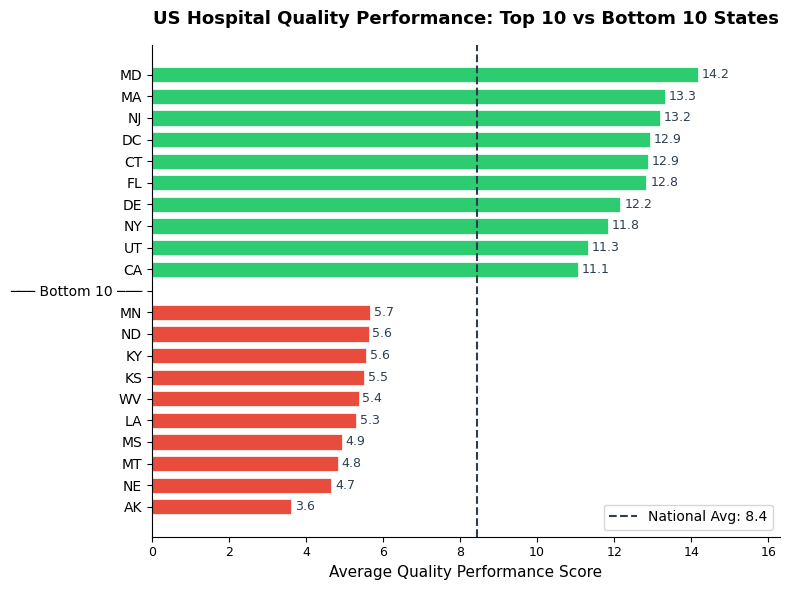

National Average Quality Performance Score: 8.43
Top state (MD): 14.18
Bottom state: 3.62
Performance gap: 10.56 points


In [20]:
# VISUALIZATION 1: Top 10 vs Bottom 10 States
# Business Question: Which states lead and lag in hospital 
# quality performance?


fig, ax = plt.subplots(figsize=(8, 6))

# Separate top and bottom for different colors
top_10 = sorted_avg.head(10)
bottom_10 = sorted_avg.tail(10)

# Combine with a separator row for visual spacing
separator = pd.DataFrame({
    'State': ['─── Bottom 10 ───'],
    'Quality_Performance_Score': [np.nan]
})
combined = pd.concat([top_10, separator, bottom_10], ignore_index=True)

# Assigning colors: green for top, gray for separator, red for bottom
colors = ['#2ECC71'] * 10 + ['white'] + ['#E74C3C'] * 10

# Plot horizontal bars
bars = ax.barh(
    combined['State'],
    combined['Quality_Performance_Score'],
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.7
)

# Add value labels on each bar
for bar, (_, row) in zip(bars, combined.iterrows()):
    if pd.notna(row['Quality_Performance_Score']):
        ax.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{row['Quality_Performance_Score']:.1f}",
            va='center',
            fontsize=9,
            color='#2C3E50'
        )

# Adding a national average reference line
national_avg = merged['Quality_Performance_Score'].mean()
ax.axvline(
    x=national_avg,
    color='#2C3E50',
    linestyle='--',
    linewidth=1.5,
    label=f'National Avg: {national_avg:.1f}'
)

# Formatting
ax.set_xlabel('Average Quality Performance Score', fontsize=11)
ax.set_title(
    'US Hospital Quality Performance: Top 10 vs Bottom 10 States',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.legend(fontsize=10)
ax.set_xlim(0, sorted_avg['Quality_Performance_Score'].max() * 1.15)
ax.invert_yaxis()  # Highest score at top
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('viz1_state_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"National Average Quality Performance Score: {national_avg:.2f}")
print(f"Top state (MD): {sorted_avg['Quality_Performance_Score'].iloc[0]:.2f}")
print(f"Bottom state: {sorted_avg['Quality_Performance_Score'].iloc[-1]:.2f}")
print(f"Performance gap: {sorted_avg['Quality_Performance_Score'].iloc[0] - sorted_avg.dropna()['Quality_Performance_Score'].iloc[-1]:.2f} points")

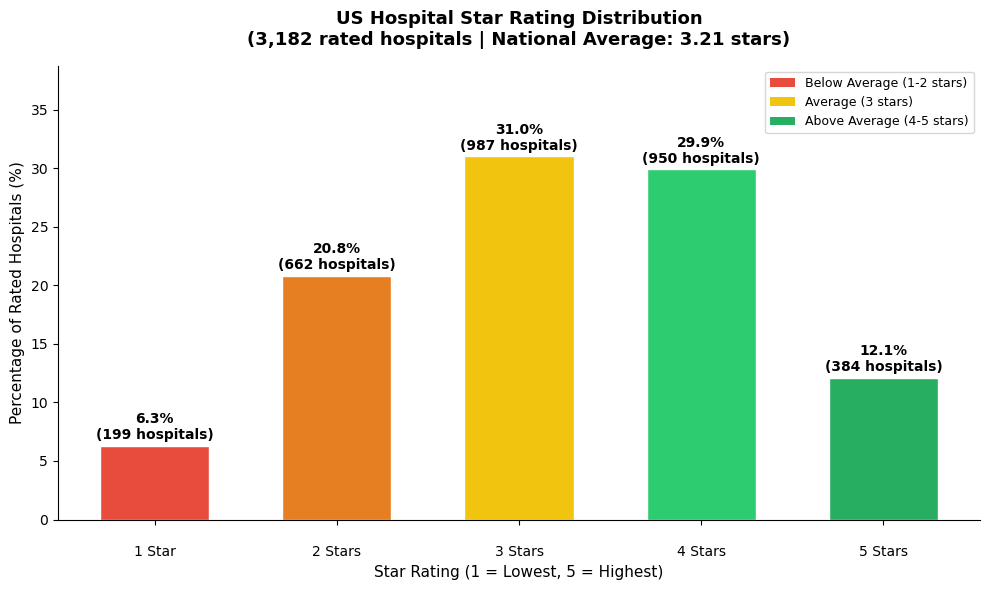

=== RATING DISTRIBUTION SUMMARY ===
1 star: 6.3% (199 hospitals)
2 star: 20.8% (662 hospitals)
3 star: 31.0% (987 hospitals)
4 star: 29.9% (950 hospitals)
5 star: 12.1% (384 hospitals)

Total rated hospitals: 3,182
Unrated hospitals: 2,250
National average rating: 3.21 stars

Below average (1-2 stars): 27.1%
Average (3 stars): 31.0%
Above average (4-5 stars): 42.0%


In [22]:
# VISUALIZATION 2: Hospital Star Rating Distribution
# Business Question: What does the national quality 
# landscape look like across all rated hospitals?

# Filter to rated hospitals only
rated = merged[merged['Hospital overall rating'].notna()].copy()

# Count and percentage by rating
rating_counts = rated['Hospital overall rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(rated) * 100).round(1)

# Create summary dataframe
rating_summary = pd.DataFrame({
    'Rating': rating_counts.index,
    'Count': rating_counts.values,
    'Percentage': rating_pct.values
})

# Color mapping: red for low, yellow for average, green for high
colors = {1: '#E74C3C', 2: '#E67E22', 3: '#F1C40F', 4: '#2ECC71', 5: '#27AE60'}
bar_colors = [colors[r] for r in rating_summary['Rating']]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    rating_summary['Rating'],
    rating_summary['Percentage'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.6
)

# Add percentage AND count labels on each bar
for bar, (_, row) in zip(bars, rating_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{row['Percentage']}%\n({int(row['Count']):,} hospitals)",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Reference line at average rating
avg_rating = rated['Hospital overall rating'].mean()
ax.axhline(y=0, color='gray', linewidth=0.5)

# Formatting
ax.set_xlabel('Star Rating (1 = Lowest, 5 = Highest)', fontsize=11)
ax.set_ylabel('Percentage of Rated Hospitals (%)', fontsize=11)
ax.set_title(
    f'US Hospital Star Rating Distribution\n'
    f'({len(rated):,} rated hospitals | National Average: {avg_rating:.2f} stars)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['\n1 Star', '\n2 Stars', '\n3 Stars',
                     '\n4 Stars', '\n5 Stars'], fontsize=10)
ax.set_ylim(0, rating_summary['Percentage'].max() * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend for color meaning
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Below Average (1-2 stars)'),
    Patch(facecolor='#F1C40F', label='Average (3 stars)'),
    Patch(facecolor='#27AE60', label='Above Average (4-5 stars)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('viz2_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== RATING DISTRIBUTION SUMMARY ===")
for _, row in rating_summary.iterrows():
    print(f"{int(row['Rating'])} star: {row['Percentage']}% ({int(row['Count']):,} hospitals)")
print(f"\nTotal rated hospitals: {len(rated):,}")
print(f"Unrated hospitals: {merged['Hospital overall rating'].isna().sum():,}")
print(f"National average rating: {avg_rating:.2f} stars")
print(f"\nBelow average (1-2 stars): {rating_summary[rating_summary['Rating'] <= 2]['Percentage'].sum():.1f}%")
print(f"Average (3 stars): {rating_summary[rating_summary['Rating'] == 3]['Percentage'].sum():.1f}%")
print(f"Above average (4-5 stars): {rating_summary[rating_summary['Rating'] >= 4]['Percentage'].sum():.1f}%")

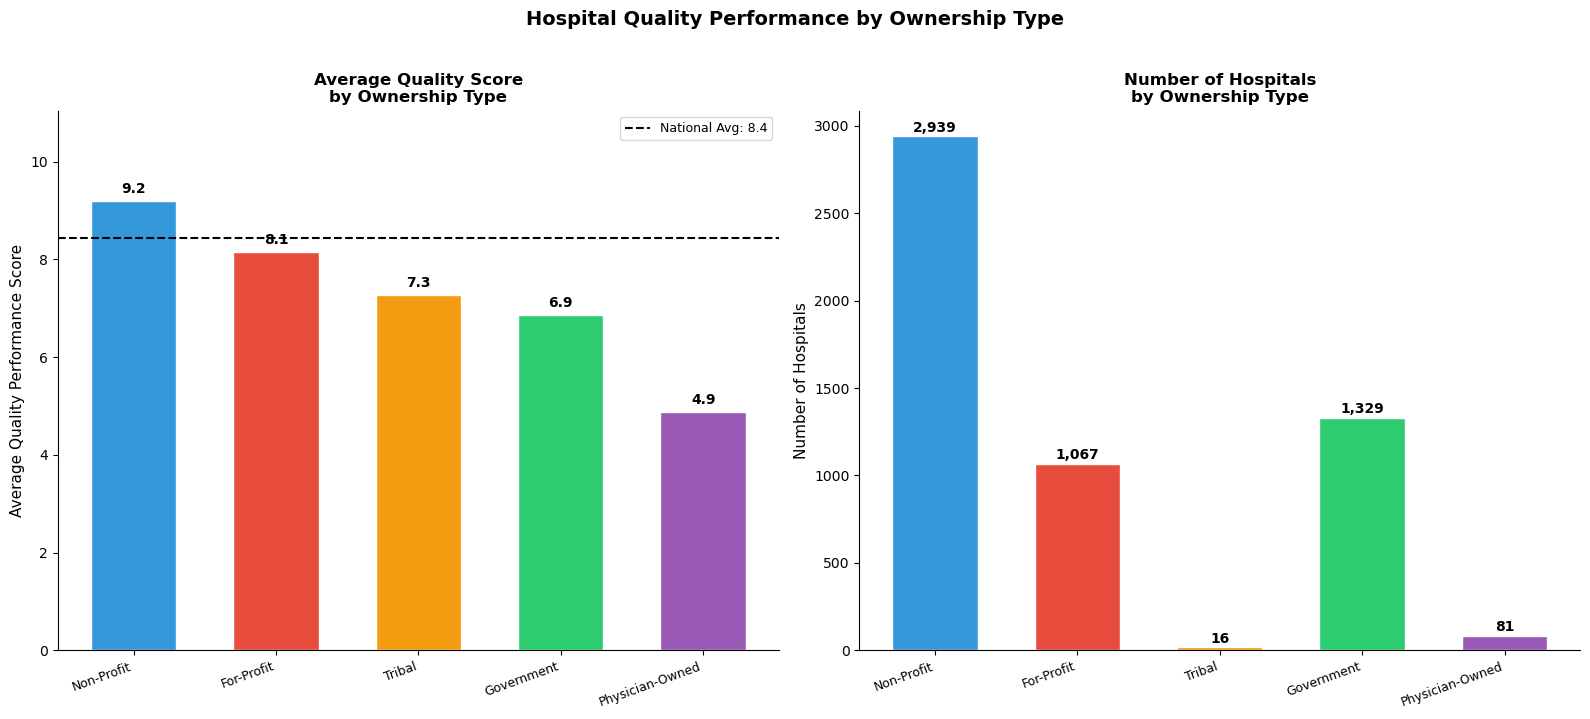

=== OWNERSHIP vs QUALITY SUMMARY ===
Ownership_Category  Avg_Quality  Hospital_Count  Avg_Rating
        Non-Profit     9.199566            2939    3.314628
        For-Profit     8.149474            1067    2.799603
            Tribal     7.264957              16    4.000000
        Government     6.858555            1329    3.157343
   Physician-Owned     4.884576              81    3.578947

National average quality score: 8.43


In [23]:
# VISUALIZATION 3: Ownership Type vs Quality Performance
# Business Question: Does ownership type impact 
# hospital quality performance?


# Calculate stats by ownership category
ownership_stats = merged.groupby('Ownership_Category').agg(
    Avg_Quality=('Quality_Performance_Score', 'mean'),
    Hospital_Count=('Facility ID', 'count'),
    Avg_Rating=('Hospital overall rating', 'mean')
).reset_index().dropna(subset=['Avg_Quality'])

# Sort by average quality descending
ownership_stats = ownership_stats.sort_values('Avg_Quality', ascending=False)

# Color palette per ownership type
ownership_colors = {
    'Non-Profit': '#3498DB',
    'For-Profit': '#E74C3C',
    'Government': '#2ECC71',
    'Physician-Owned': '#9B59B6',
    'Tribal': '#F39C12',
    'Other': '#95A5A6'
}
bar_colors = [ownership_colors.get(o, '#95A5A6') 
              for o in ownership_stats['Ownership_Category']]

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

#LEFT CHART: Average Quality Score by Ownership
bars = ax1.bar(
    range(len(ownership_stats)),
    ownership_stats['Avg_Quality'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.6
)

# National average line
national_avg = merged['Quality_Performance_Score'].mean()
ax1.axhline(
    y=national_avg,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'National Avg: {national_avg:.1f}'
)

# Value labels on bars
for bar, (_, row) in zip(bars, ownership_stats.iterrows()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{row['Avg_Quality']:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax1.set_xticks(range(len(ownership_stats)))
ax1.set_xticklabels(
    ownership_stats['Ownership_Category'],
    rotation=20,
    ha='right',
    fontsize=9
)
ax1.set_ylabel('Average Quality Performance Score', fontsize=11)
ax1.set_title('Average Quality Score\nby Ownership Type', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, ownership_stats['Avg_Quality'].max() * 1.2)

#RIGHT CHART: Hospital Count by Ownership
ax2.bar(
    range(len(ownership_stats)),
    ownership_stats['Hospital_Count'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.6
)

# Count labels
for i, (_, row) in enumerate(ownership_stats.iterrows()):
    ax2.text(
        i,
        row['Hospital_Count'] + 10,
        f"{int(row['Hospital_Count']):,}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax2.set_xticks(range(len(ownership_stats)))
ax2.set_xticklabels(
    ownership_stats['Ownership_Category'],
    rotation=20,
    ha='right',
    fontsize=9
)
ax2.set_ylabel('Number of Hospitals', fontsize=11)
ax2.set_title('Number of Hospitals\nby Ownership Type', fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle(
    'Hospital Quality Performance by Ownership Type',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('viz3_ownership_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("=== OWNERSHIP vs QUALITY SUMMARY ===")
print(ownership_stats[['Ownership_Category', 'Avg_Quality', 
                         'Hospital_Count', 'Avg_Rating']].to_string(index=False))
print(f"\nNational average quality score: {national_avg:.2f}")

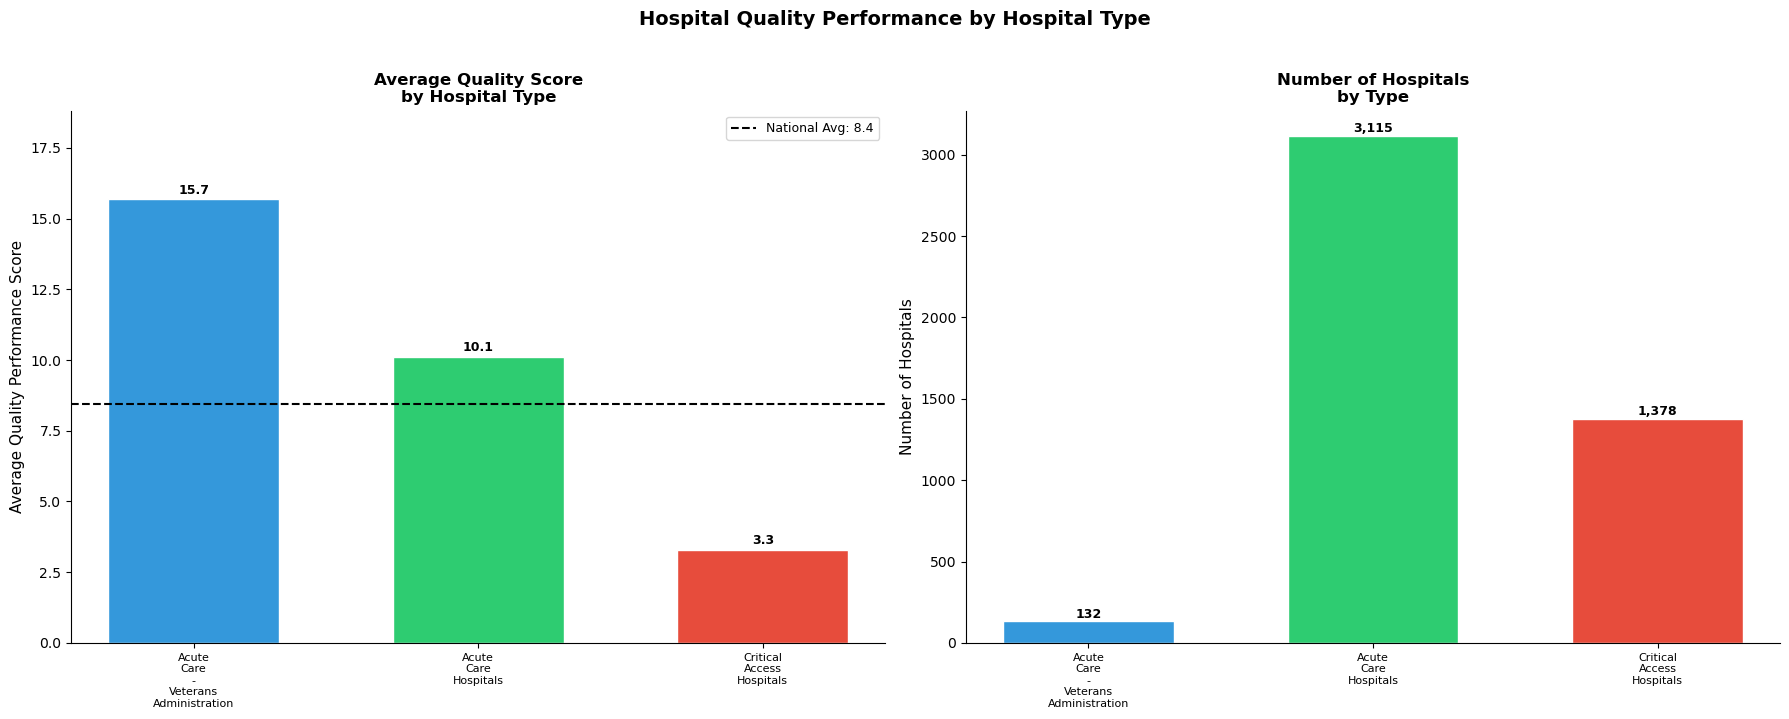

=== HOSPITAL TYPE vs QUALITY SUMMARY ===
                       Hospital Type  Avg_Quality  Hospital_Count  Avg_Rating
Acute Care - Veterans Administration    15.677507             132    4.160714
                Acute Care Hospitals    10.120172            3115    3.164045
           Critical Access Hospitals     3.275539            1378    3.225000

National average: 8.43


In [24]:
# VISUALIZATION 4: Hospital Type vs Quality Performance
# Business Question: Which hospital types consistently 
# deliver the highest quality care?

# Calculate stats by hospital type
type_stats = merged.groupby('Hospital Type').agg(
    Avg_Quality=('Quality_Performance_Score', 'mean'),
    Hospital_Count=('Facility ID', 'count'),
    Avg_Rating=('Hospital overall rating', 'mean')
).reset_index().dropna(subset=['Avg_Quality'])

type_stats = type_stats.sort_values('Avg_Quality', ascending=False)

# Color palette
type_colors = ['#3498DB','#2ECC71','#E74C3C','#9B59B6',
               '#F39C12','#1ABC9C','#E67E22','#95A5A6']
bar_colors = type_colors[:len(type_stats)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT: Average Quality Score ---
bars = ax1.bar(
    range(len(type_stats)),
    type_stats['Avg_Quality'],
    color=bar_colors,
    edgecolor='white',
    width=0.6
)

national_avg = merged['Quality_Performance_Score'].mean()
ax1.axhline(y=national_avg, color='black', linestyle='--',
            linewidth=1.5, label=f'National Avg: {national_avg:.1f}')

for bar, (_, row) in zip(bars, type_stats.iterrows()):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{row['Avg_Quality']:.1f}",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

ax1.set_xticks(range(len(type_stats)))
ax1.set_xticklabels(
    [t.replace(' ', '\n') for t in type_stats['Hospital Type']],
    fontsize=8, ha='center'
)
ax1.set_ylabel('Average Quality Performance Score', fontsize=11)
ax1.set_title('Average Quality Score\nby Hospital Type',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, type_stats['Avg_Quality'].max() * 1.2)

#RIGHT: Hospital Count
ax2.bar(
    range(len(type_stats)),
    type_stats['Hospital_Count'],
    color=bar_colors,
    edgecolor='white',
    width=0.6
)

for i, (_, row) in enumerate(type_stats.iterrows()):
    ax2.text(
        i, row['Hospital_Count'] + 5,
        f"{int(row['Hospital_Count']):,}",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

ax2.set_xticks(range(len(type_stats)))
ax2.set_xticklabels(
    [t.replace(' ', '\n') for t in type_stats['Hospital Type']],
    fontsize=8, ha='center'
)
ax2.set_ylabel('Number of Hospitals', fontsize=11)
ax2.set_title('Number of Hospitals\nby Type',
              fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Hospital Quality Performance by Hospital Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz4_type_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== HOSPITAL TYPE vs QUALITY SUMMARY ===")
print(type_stats[['Hospital Type','Avg_Quality',
                   'Hospital_Count','Avg_Rating']].to_string(index=False))
print(f"\nNational average: {national_avg:.2f}")

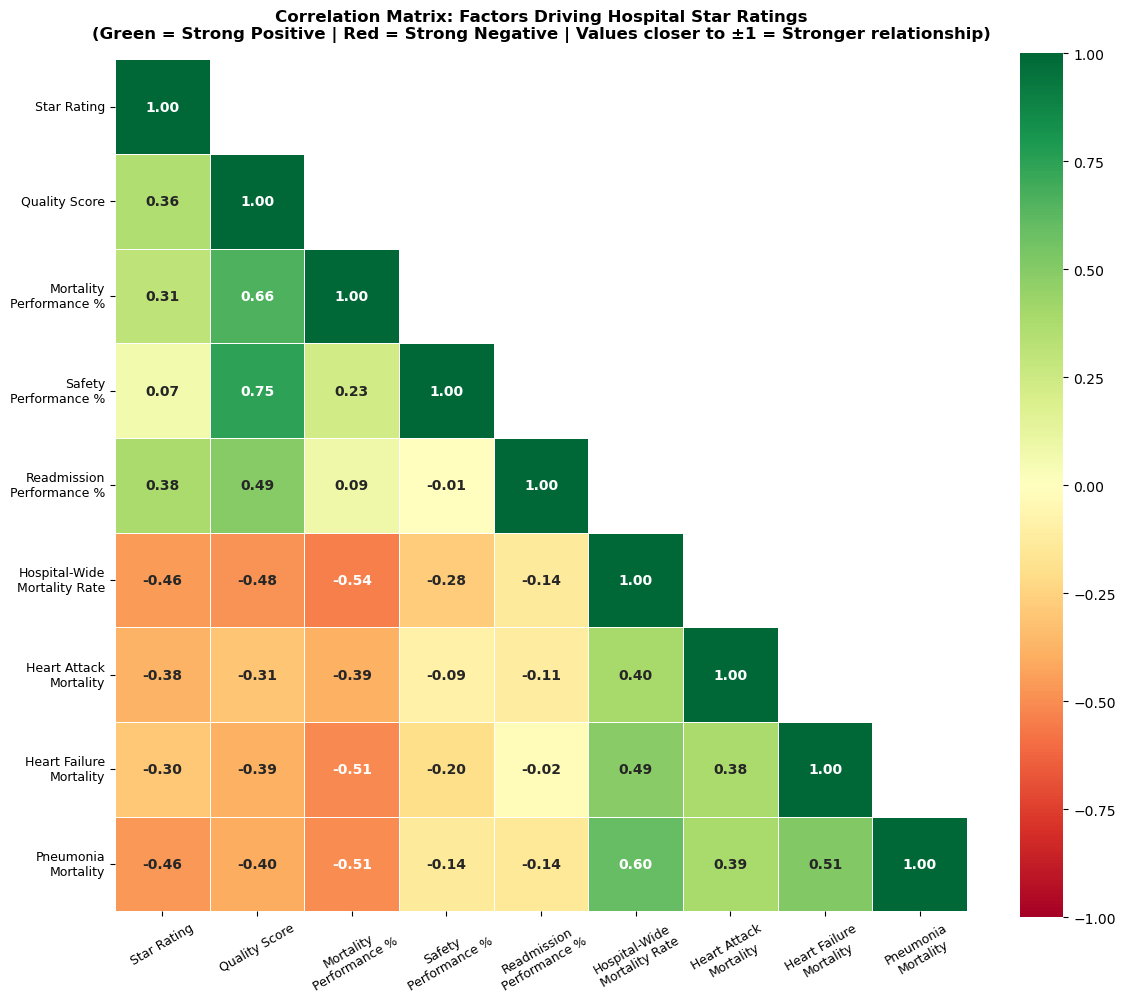

=== CORRELATIONS WITH STAR RATING ===
Pneumonia
Mortality: -0.462 (Moderate negative)
Hospital-Wide
Mortality Rate: -0.455 (Moderate negative)
Readmission
Performance %: 0.377 (Moderate positive)
Heart Attack
Mortality: -0.376 (Moderate negative)
Quality Score: 0.358 (Moderate positive)
Mortality
Performance %: 0.306 (Moderate positive)
Heart Failure
Mortality: -0.296 (Weak negative)
Safety
Performance %: 0.069 (Weak positive)


In [29]:
# VISUALIZATION 5: Correlation Heatmap


# Select relevant numeric columns for correlation
corr_cols = [
    'Hospital overall rating',
    'Quality_Performance_Score',
    'MORT_Better_Pct',
    'Safety_Better_Pct',
    'READM_Better_Pct',
    'HospitalWide_Mortality',
    'Mortality_HeartAttack',
    'Mortality_HeartFailure',
    'Mortality_Pneumonia'
]

# Filter to only hospitals with ratings and calculate correlation
corr_df = merged[corr_cols].dropna(subset=['Hospital overall rating'])
corr_matrix = corr_df.corr()

# Rename for cleaner labels
label_map = {
    'Hospital overall rating': 'Star Rating',
    'Quality_Performance_Score': 'Quality Score',
    'MORT_Better_Pct': 'Mortality\nPerformance %',
    'Safety_Better_Pct': 'Safety\nPerformance %',
    'READM_Better_Pct': 'Readmission\nPerformance %',
    'HospitalWide_Mortality': 'Hospital-Wide\nMortality Rate',
    'Mortality_HeartAttack': 'Heart Attack\nMortality',
    'Mortality_HeartFailure': 'Heart Failure\nMortality',
    'Mortality_Pneumonia': 'Pneumonia\nMortality'
}

corr_matrix_labeled = corr_matrix.rename(
    index=label_map, columns=label_map)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.zeros_like(corr_matrix_labeled, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_matrix_labeled,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    ax=ax
)

ax.set_title(
    'Correlation Matrix: Factors Driving Hospital Star Ratings\n'
    '(Green = Strong Positive | Red = Strong Negative | '
    'Values closer to ±1 = Stronger relationship)',
    fontsize=12,
    fontweight='bold',
    pad=15
)
ax.tick_params(axis='x', labelsize=9, rotation=30)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig('viz5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key correlations with Star Rating
print("=== CORRELATIONS WITH STAR RATING ===")
star_corr = corr_matrix['Hospital overall rating'].drop(
    'Hospital overall rating').sort_values(
    ascending=False, key=abs)

for col, val in star_corr.items():
    strength = "Strong" if abs(val) > 0.5 else \
               "Moderate" if abs(val) > 0.3 else "Weak"
    direction = "positive" if val > 0 else "negative"
    print(f"{label_map.get(col, col)}: {val:.3f} "
          f"({strength} {direction})")